# PFLOTRAN Kernel Case Study: Learning a Relative Permeability Closure

This notebook demonstrates the core Trusty Neurocoder pattern on a **PFLOTRAN-style reactive transport kernel**:

- keep the transport and sorption scaffold fixed
- treat saturation-dependent relative permeability `k_rel(S)` as the uncertain closure
- train only that closure from simulator-generated trajectories
- verify conserved tracer mass and non-negativity after training

[PFLOTRAN](https://www.pflotran.org/) is an open-source, massively parallel code for **subsurface flow and reactive transport**, with official documentation at <https://documentation.pflotran.org/> and a detailed [User's Guide](https://documentation.pflotran.org/user_guide/user_guide.html). It is used for hydrogeologic and geochemical problems such as contaminant transport, multiphase flow, carbon storage, geothermal systems, and reactive transport in porous media. In those settings, constitutive closures such as relative permeability, capillary pressure, and sorption laws strongly control plume migration and reaction fronts.

The notebook focuses on one such closure: the dependence of effective mobility on saturation. In multiphase subsurface flow, relative permeability `k_rel(S)` controls how easily a fluid phase moves through partially saturated porous media. This matters whenever saturation changes appreciably, for example in vadose-zone transport, brine/CO2 systems, infiltration, drainage, or other unsaturated and multiphase hydrogeologic settings.

The kernel here is a simple two-cell control-volume model:

```python
adv_flux = v * k_rel(S) * C_up
ads_flux = k_ads * C_down * (Q_max - C_sorb)
```

This is **not** a full PFLOTRAN integration and it is **not** meant to represent a particular physical domain such as `1 cm^2` or `10 km^2` directly. Instead, it approximates a **local constitutive kernel** that could appear inside simulations spanning many scales, from laboratory core or column experiments to field-scale aquifer and reservoir models. The notebook is therefore about learning a scientifically meaningful closure at the cell or local-process level, not about replacing the entire subsurface simulator.

## Scientific Structure

Conceptually, the notebook simulates a small **subsurface transport-and-sorption problem**. A dissolved tracer starts in an upstream control volume, moves advectively into a downstream control volume, and can sorb onto an immobile phase there. The moving quantity is therefore the **mobile aqueous inventory**, while the sorbed quantity represents mass temporarily removed from the mobile phase but still present in the local mass balance.

This is deliberately minimal, but it captures a recognizable hydrogeologic pattern:

- transport is controlled by a mobility factor that depends on saturation
- downstream retention is controlled by a nonlinear sorption capacity
- total tracer mass should remain conserved across mobile and sorbed phases

We treat the following pieces as **known**:

- one upstream mobile inventory `C_up`
- one downstream mobile inventory `C_down`
- one downstream sorbed inventory `C_sorb`
- advection from upstream to downstream
- capacity-limited sorption in the downstream cell
- total tracer mass conserved across mobile and sorbed phases

We treat the following piece as **unknown and learnable**:

- relative permeability / mobility closure `k_rel(S)` as a function of saturation

In a full PFLOTRAN setting, analogous closures would appear inside the discretized flow and transport equations for porous media and would strongly influence plume travel time, effective arrival mass, and the coupling between flow state and geochemical evolution. The notebook isolates that closure to make the learning problem interpretable.

The hidden ground truth is a **Corey-style power law** in effective saturation. That is a standard constitutive form in porous-media flow: effective mobility is near zero at low effective saturation and rises nonlinearly as the flowing phase becomes better connected. Training data comes from a `3 x 3` grid of saturation and injected-mass conditions generated by the hidden kernel.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyReal
from cajal.compiling import compile, TypedTensor

matplotlib.rcParams['figure.dpi'] = 120
torch.manual_seed(0)
device = torch.device('cpu')

DT = 0.25
N_STEPS = 10
ADV_RATE = 0.9
SORP_RATE = 0.35
Q_MAX = 0.6
S_RES = 0.2

SATURATIONS = torch.tensor([0.32, 0.58, 0.84], device=device)
INITIAL_MASSES = torch.tensor([0.4, 0.7, 1.0], device=device)

In [2]:
def effective_saturation(S):
    return torch.clamp((S - S_RES) / (1.0 - S_RES), 0.0, 1.0)


def true_k_rel(S):
    """Hidden PFLOTRAN-style Corey relative permeability."""
    return effective_saturation(S) ** 3


def generate_trajectories():
    conditions = []
    curves = []

    for S in SATURATIONS:
        for injected_mass in INITIAL_MASSES:
            c_up = float(injected_mass)
            c_down = 0.0
            c_sorb = 0.0
            curve = []

            for _ in range(N_STEPS):
                curve.append(torch.tensor([c_up, c_down, c_sorb], dtype=torch.float32))

                mobility = true_k_rel(S).item()
                adv_flux = ADV_RATE * mobility * c_up * DT
                c_up_mid = c_up - adv_flux
                c_down_mid = c_down + adv_flux

                sorp_flux = SORP_RATE * c_down_mid * (Q_MAX - c_sorb) * DT

                c_up = c_up_mid
                c_down = c_down_mid - sorp_flux
                c_sorb = c_sorb + sorp_flux

            conditions.append((S.item(), injected_mass.item()))
            curves.append(torch.stack(curve))

    return conditions, curves


conditions, true_curves = generate_trajectories()
N_TRAJ = len(conditions)
conditions

[(0.3199999928474426, 0.4000000059604645),
 (0.3199999928474426, 0.699999988079071),
 (0.3199999928474426, 1.0),
 (0.5799999833106995, 0.4000000059604645),
 (0.5799999833106995, 0.699999988079071),
 (0.5799999833106995, 1.0),
 (0.8399999737739563, 0.4000000059604645),
 (0.8399999737739563, 0.699999988079071),
 (0.8399999737739563, 1.0)]

## Synthetic Training Set

The printed list is the full `3 x 3` design of experiments: three water saturations crossed with three injected tracer masses. Each pair defines one rollout of the local state

- `C_up`: dissolved tracer still upstream of the local interface
- `C_down`: dissolved tracer that has advected into the downstream control volume
- `C_sorb`: tracer that has transferred into the sorbed inventory

Higher saturation implies higher mobility through `k_rel(S)`, so more tracer should move downstream and become available for sorption. In a full PFLOTRAN setting these local laws are embedded in much larger subsurface simulations; here we isolate the closure-learning problem so the structure is easy to inspect.

In [3]:
class RelPermMLP(nn.Module):
    """Learn k_rel(S) with output constrained to [0, 1]."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 16), nn.Tanh(),
            nn.Linear(16, 1), nn.Sigmoid(),
        )

    def forward(self, S):
        s_norm = (S - float(SATURATIONS.min())) / float(SATURATIONS.max() - SATURATIONS.min())
        return self.net(s_norm.view(1, 1)).squeeze()


class PFLOTRANTransportUpdate(nn.Module):
    """One structured transport-plus-sorption update.

    State: [C_up, C_down, C_sorb, S]

    Known structure:
        adv_flux = v * k_rel(S) * C_up * dt
        ads_flux = k_ads * C_down * (Q_max - C_sorb) * dt

    Unknown closure:
        k_rel(S)
    """

    def __init__(self, adv_rate, sorp_rate, q_max, dt, rel_perm):
        super().__init__()
        self.adv_rate = adv_rate
        self.sorp_rate = sorp_rate
        self.q_max = q_max
        self.dt = dt
        self.rel_perm = rel_perm

    def forward(self, state):
        c_up = state.data[0]
        c_down = state.data[1]
        c_sorb = state.data[2]
        S = state.data[3]

        mobility = self.rel_perm(S)
        adv_flux = self.adv_rate * mobility * c_up * self.dt
        c_up_mid = c_up - adv_flux
        c_down_mid = c_down + adv_flux

        sorp_flux = self.sorp_rate * c_down_mid * (self.q_max - c_sorb) * self.dt

        return TypedTensor(
            torch.stack([c_up_mid, c_down_mid - sorp_flux, c_sorb + sorp_flux, S]),
            state.ty,
        )


program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

rel_perm_mlp = RelPermMLP()
update_fn = PFLOTRANTransportUpdate(ADV_RATE, SORP_RATE, Q_MAX, DT, rel_perm_mlp)
optimizer = torch.optim.Adam(rel_perm_mlp.parameters(), lr=0.01)


def rollout(update_fn, s0_values):
    s0 = TypedTensor(torch.tensor(s0_values, dtype=torch.float32), TyReal(4))
    trajectory = []

    for step in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS)
        n_onehot[step] = 1.0
        result = compiled({
            's0': s0,
            'f': lambda s, _fn=update_fn: _fn(s),
            'n': TypedTensor(n_onehot, TyNat()),
        })
        trajectory.append(result.data[:3])

    return torch.stack(trajectory)

## Structured Update, Learned Closure

This cell separates what is known from what is learned.

- The **transport scaffold** is fixed: advective flux moves dissolved tracer from `C_up` to `C_down`, and a sorption term transfers mass from `C_down` into `C_sorb`.
- The only learned object is the closure `k_rel(S)`, represented here by a small MLP constrained to output values in `[0, 1]`.
- `TmIter` provides the repeated application of the one-step update, so the model is trained against full rollouts rather than isolated regression targets.

That is the main neuro-symbolic point of the example: we are not learning an unconstrained emulator of the entire kernel. We are learning one uncertain constitutive relation inside an explicit balance-law update.

In [4]:
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)

    for traj_idx, (S, injected_mass) in enumerate(conditions):
        predicted = rollout(update_fn, [injected_mass, 0.0, 0.0, S])
        truth = true_curves[traj_idx]
        total_loss = total_loss + ((predicted - truth) ** 2).sum()

    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())

    if epoch % 25 == 0 or epoch == 99:
        print(f'epoch {epoch:3d}  loss={total_loss.item():.6f}')

epoch   0  loss=10.460019


epoch  25  loss=2.928597


epoch  50  loss=1.196821


epoch  75  loss=0.040872


epoch  99  loss=0.014038


## Training Signal

The loss is the summed squared trajectory mismatch over all nine experiments. The same learned closure must explain every rollout simultaneously, so this is a consistency test across operating conditions rather than nine unrelated fits. A strong loss drop means the learned `k_rel(S)` is producing the right time evolution for dissolved and sorbed inventories together, not just matching one scalar summary statistic.

In [5]:
S_test = torch.linspace(0.25, 0.95, 50)

with torch.no_grad():
    true_rel_perm = true_k_rel(S_test)
    learned_rel_perm = torch.tensor([rel_perm_mlp(S).item() for S in S_test])

pred_curves = []
all_nonnegative = True
mass_conserved = True
sorbed_bounded = True
max_mass_drift = 0.0

for traj_idx, (S, injected_mass) in enumerate(conditions):
    predicted = rollout(update_fn, [injected_mass, 0.0, 0.0, S]).detach()
    pred_curves.append(predicted)

    totals = predicted.sum(dim=1)
    max_mass_drift = max(max_mass_drift, float(torch.max(torch.abs(totals - injected_mass))))
    all_nonnegative = all_nonnegative and not (predicted < -1e-9).any().item()
    mass_conserved = mass_conserved and torch.allclose(
        totals,
        torch.full_like(totals, injected_mass),
        atol=1e-5,
    )
    sorbed_bounded = sorbed_bounded and bool((predicted[:, 2] <= Q_MAX + 1e-6).all().item())

pred_curves = [traj.cpu() for traj in pred_curves]

s_eff_test = effective_saturation(S_test)
best_mse = float('inf')
best_scale = None
best_exp = None

for scale_try in torch.linspace(0.7, 1.2, 101):
    for exp_try in torch.linspace(1.0, 5.0, 161):
        candidate = scale_try * (s_eff_test ** exp_try)
        mse = ((candidate - learned_rel_perm) ** 2).mean().item()
        if mse < best_mse:
            best_mse = mse
            best_scale = scale_try.item()
            best_exp = exp_try.item()

fit_curve = best_scale * (s_eff_test ** best_exp)

print(f'final loss: {losses[-1]:.6f}')
print(f'all inventories non-negative: {all_nonnegative}')
print(f'tracer mass conserved: {mass_conserved}')
print(f'sorbed inventory stays below Q_max: {sorbed_bounded}')
print(f'max mass drift across all trajectories: {max_mass_drift:.2e}')
print(f'best power-law fit to learned closure: {best_scale:.3f} * S_eff^{best_exp:.3f}  (MSE={best_mse:.6f})')

final loss: 0.014038
all inventories non-negative: True
tracer mass conserved: True
sorbed inventory stays below Q_max: True
max mass drift across all trajectories: 1.19e-07
best power-law fit to learned closure: 0.825 * S_eff^2.400  (MSE=0.000357)


## Diagnostic Checks Before Plotting

These printed diagnostics answer the basic scientific sanity questions.

- **Non-negativity** checks that the learned rollout stays in an admissible concentration range.
- **Mass conservation** confirms that the learned closure changes how flux is partitioned, but does not create or destroy tracer.
- **Capacity bounds** verify that sorption never exceeds the prescribed `Q_max`.
- The **best power-law fit** asks whether the learned neural closure can be summarized by a simpler symbolic constitutive law, which is the first step toward decompilation back into a compact interpretable relation.

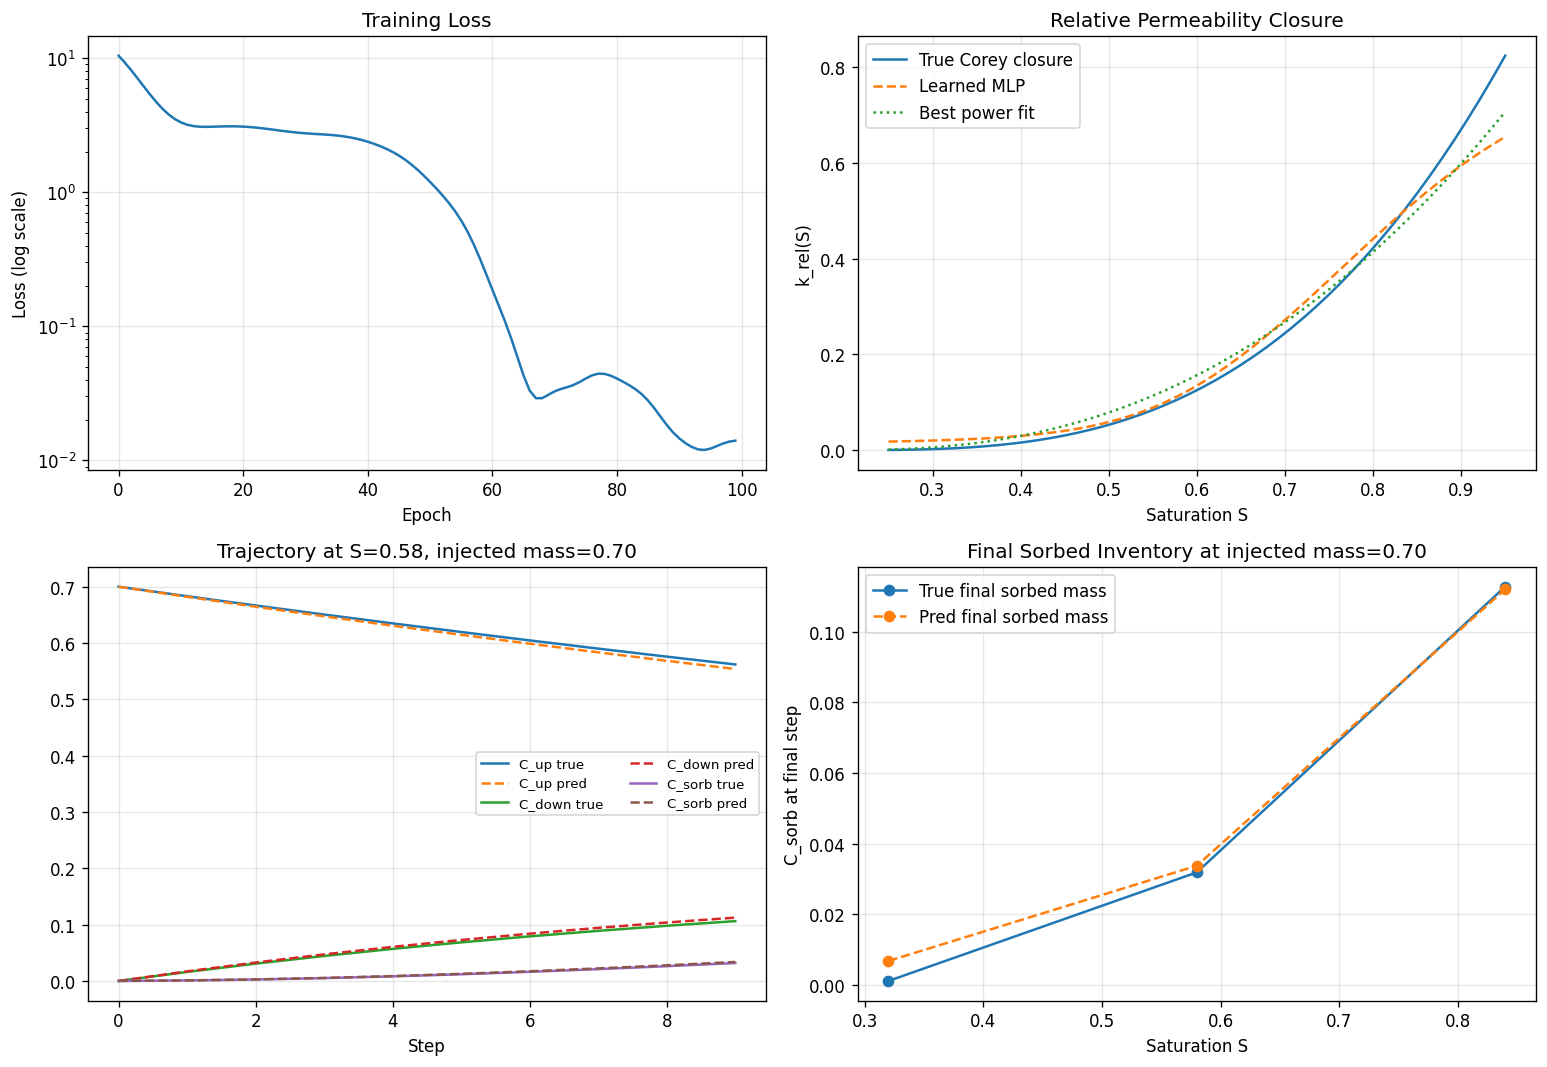

In [6]:
ref_idx = 4  # middle trajectory in the 3x3 grid
S_ref, injected_ref = conditions[ref_idx]
true_traj = true_curves[ref_idx].cpu()
pred_traj = pred_curves[ref_idx]

probe_mass = INITIAL_MASSES[1].item()
probe_indices = [idx for idx, (_, injected_mass) in enumerate(conditions) if abs(injected_mass - probe_mass) < 1e-9]
probe_sats = [conditions[idx][0] for idx in probe_indices]
true_final_sorbed = [true_curves[idx][-1, 2].item() for idx in probe_indices]
pred_final_sorbed = [pred_curves[idx][-1, 2].item() for idx in probe_indices]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].semilogy(losses)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log scale)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(S_test.numpy(), true_rel_perm.numpy(), label='True Corey closure')
axes[0, 1].plot(S_test.numpy(), learned_rel_perm.numpy(), '--', label='Learned MLP')
axes[0, 1].plot(S_test.numpy(), fit_curve.numpy(), ':', label='Best power fit')
axes[0, 1].set_title('Relative Permeability Closure')
axes[0, 1].set_xlabel('Saturation S')
axes[0, 1].set_ylabel('k_rel(S)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

labels = ['C_up', 'C_down', 'C_sorb']
for idx, label in enumerate(labels):
    axes[1, 0].plot(true_traj[:, idx].numpy(), label=f'{label} true')
    axes[1, 0].plot(pred_traj[:, idx].numpy(), '--', label=f'{label} pred')
axes[1, 0].set_title(f'Trajectory at S={S_ref:.2f}, injected mass={injected_ref:.2f}')
axes[1, 0].set_xlabel('Step')
axes[1, 0].legend(ncol=2, fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(probe_sats, true_final_sorbed, marker='o', label='True final sorbed mass')
axes[1, 1].plot(probe_sats, pred_final_sorbed, '--', marker='o', label='Pred final sorbed mass')
axes[1, 1].set_title(f'Final Sorbed Inventory at injected mass={probe_mass:.2f}')
axes[1, 1].set_xlabel('Saturation S')
axes[1, 1].set_ylabel('C_sorb at final step')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Takeaway

This notebook shows the intended PFLOTRAN-style value proposition in compact form:

- the **transport and sorption scaffold** stays fixed
- the uncertain constitutive term is isolated as an explicit closure `k_rel(S)`
- learning uses only **simulator-generated trajectories**
- physically meaningful checks like **mass conservation**, **non-negativity**, and **capacity bounds** remain inspectable after training

That is the core distinction from replacing the whole kernel with a black-box surrogate.